# Ablation Study Report — Bowel Sound Classification

This notebook presents a structured comparison of baseline models vs preprocessed models, a per-component ablation study on preprocessing, and an error analysis of the best model.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch
import librosa
import librosa.display
from pathlib import Path

sys.path.insert(0, str(Path("../src").resolve()))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

EXPERIMENTS_DIR = Path("../experiments")
RESULTS_DIR = Path("../results")
FIG_DIR = Path("figures/ablation")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load aggregated results
df = pd.read_csv(RESULTS_DIR / "all_results.csv")
print(f"Loaded {len(df)} experiment results")
df

Loaded 10 experiment results


,experiment,model,preprocessing,macro_f1,f1_b,f1_mb,f1_h,precision_macro,recall_macro
0,ablation_cnn_bandpass,resnet_cnn,bandpass,0.9104,0.9440,0.9302,0.8571,0.9545,0.8784
1,baseline_panns,panns,none,0.8828,0.9245,0.9115,0.8125,0.8827,0.8831
2,pp_crnn,crnn,all,0.8662,0.9136,0.8954,0.7895,0.8361,0.9103
3,baseline_cnn,resnet_cnn,none,0.8575,0.9254,0.8970,0.7500,0.8575,0.8574
4,ablation_cnn_augmentation,resnet_cnn,augmentation,0.8458,0.9240,0.8911,0.7222,0.8255,0.8722
5,pp_panns,panns,all,0.8301,0.8966,0.8795,0.7143,0.7944,0.8959
6,ablation_cnn_normalise,resnet_cnn,normalise,0.8276,0.9244,0.8741,0.6842,0.8050,0.8641
7,pp_cnn,resnet_cnn,all,0.8265,0.8924,0.8690,0.7179,0.7982,0.8733
8,ablation_cnn_all,resnet_cnn,all_ablation,0.8265,0.8924,0.8690,0.7179,0.7982,0.8733
9,baseline_crnn,crnn,none,0.7887,0.8953,0.8392,0.6316,0.7682,0.8223


## Section 1 — Experiment Overview

Full table of all runs with the best value in each metric column highlighted.

In [2]:
# Highlight best values per metric column
metric_cols = ["macro_f1", "f1_b", "f1_mb", "f1_h", "precision_macro", "recall_macro"]

def highlight_max(s):
    is_max = s == s.max()
    return ["font-weight: bold; background-color: #d4edda" if v else "" for v in is_max]

styled = df.style.apply(highlight_max, subset=metric_cols)
styled

,experiment,model,preprocessing,macro_f1,f1_b,f1_mb,f1_h,precision_macro,recall_macro
0,ablation_cnn_bandpass,resnet_cnn,bandpass,0.910400,0.944000,0.930200,0.857100,0.954500,0.878400
1,baseline_panns,panns,none,0.882800,0.924500,0.911500,0.812500,0.882700,0.883100
2,pp_crnn,crnn,all,0.866200,0.913600,0.895400,0.789500,0.836100,0.910300
3,baseline_cnn,resnet_cnn,none,0.857500,0.925400,0.897000,0.750000,0.857500,0.857400
4,ablation_cnn_augmentation,resnet_cnn,augmentation,0.845800,0.924000,0.891100,0.722200,0.825500,0.872200
5,pp_panns,panns,all,0.830100,0.896600,0.879500,0.714300,0.794400,0.895900
6,ablation_cnn_normalise,resnet_cnn,normalise,0.827600,0.924400,0.874100,0.684200,0.805000,0.864100
7,pp_cnn,resnet_cnn,all,0.826500,0.892400,0.869000,0.717900,0.798200,0.873300
8,ablation_cnn_all,resnet_cnn,all_ablation,0.826500,0.892400,0.869000,0.717900,0.798200,0.873300
9,baseline_crnn,crnn,none,0.788700,0.895300,0.839200,0.631600,0.768200,0.822300


## Section 2 — Baseline vs Preprocessed Comparison

Grouped bar chart: 3 model groups x 2 bars (baseline vs preprocessed). Metric: macro-F1.

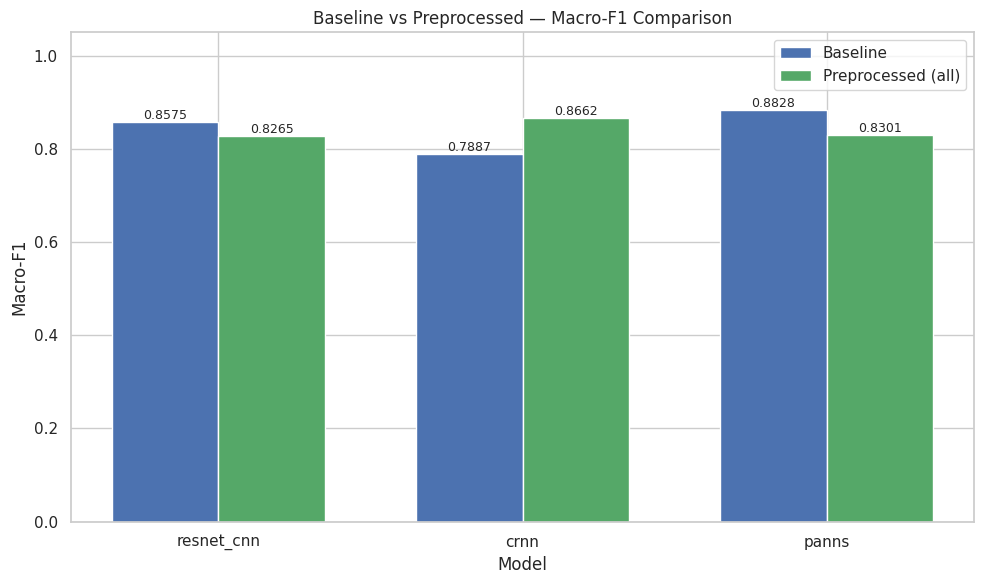


Delta (preprocessed - baseline):
  resnet_cnn: -0.0310 (declined)
  crnn: +0.0775 (improved)
  panns: -0.0527 (declined)


In [3]:
# Extract baseline and preprocessed runs for the 3 models
models = ["resnet_cnn", "crnn", "panns"]
baseline_exps = ["baseline_cnn", "baseline_crnn", "baseline_panns"]
pp_exps = ["pp_cnn", "pp_crnn", "pp_panns"]

baseline_f1 = [df[df["experiment"] == e]["macro_f1"].values[0] for e in baseline_exps]
pp_f1 = [df[df["experiment"] == e]["macro_f1"].values[0] for e in pp_exps]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_f1, width, label="Baseline", color="#4C72B0")
bars2 = ax.bar(x + width/2, pp_f1, width, label="Preprocessed (all)", color="#55A868")
ax.bar_label(bars1, fmt="%.4f", fontsize=9)
ax.bar_label(bars2, fmt="%.4f", fontsize=9)
ax.set_xlabel("Model")
ax.set_ylabel("Macro-F1")
ax.set_title("Baseline vs Preprocessed — Macro-F1 Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_vs_preprocessed.png", dpi=150)
plt.show()

# Print delta
print("\nDelta (preprocessed - baseline):")
for m, b, p in zip(models, baseline_f1, pp_f1):
    delta = p - b
    print(f"  {m}: {delta:+.4f} ({'improved' if delta > 0 else 'declined'})")

## Section 3 — Per-Class Analysis

Heatmap showing F1 scores per class across all experiments. Identifies which model/config performs best and worst for each class.

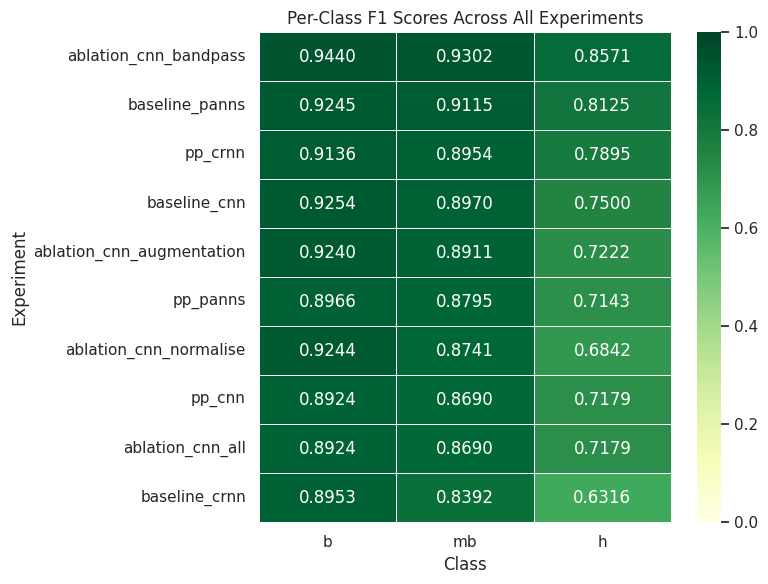

Class b:
  Best:  ablation_cnn_bandpass (F1=0.9440)
  Worst: pp_cnn (F1=0.8924)
Class mb:
  Best:  ablation_cnn_bandpass (F1=0.9302)
  Worst: baseline_crnn (F1=0.8392)
Class h:
  Best:  ablation_cnn_bandpass (F1=0.8571)
  Worst: baseline_crnn (F1=0.6316)


In [4]:
# Heatmap: rows=experiments, columns=classes
heatmap_data = df.set_index("experiment")[["f1_b", "f1_mb", "f1_h"]]
heatmap_data.columns = ["b", "mb", "h"]

fig, ax = plt.subplots(figsize=(8, max(6, len(df) * 0.5)))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGn", ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title("Per-Class F1 Scores Across All Experiments")
ax.set_ylabel("Experiment")
ax.set_xlabel("Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_heatmap.png", dpi=150)
plt.show()

# Best/worst per class
for cls in ["b", "mb", "h"]:
    col = f"f1_{cls}"
    best_row = df.loc[df[col].idxmax()]
    worst_row = df.loc[df[col].idxmin()]
    print(f"Class {cls}:")
    print(f"  Best:  {best_row['experiment']} (F1={best_row[col]:.4f})")
    print(f"  Worst: {worst_row['experiment']} (F1={worst_row[col]:.4f})")

## Section 4 — Preprocessing Ablation (M1: ResNet CNN)

Core ablation result: macro-F1 for each preprocessing variant applied to ResNet CNN.  
Variants: none (baseline) -> bandpass only -> normalise only -> augmentation only -> all combined.

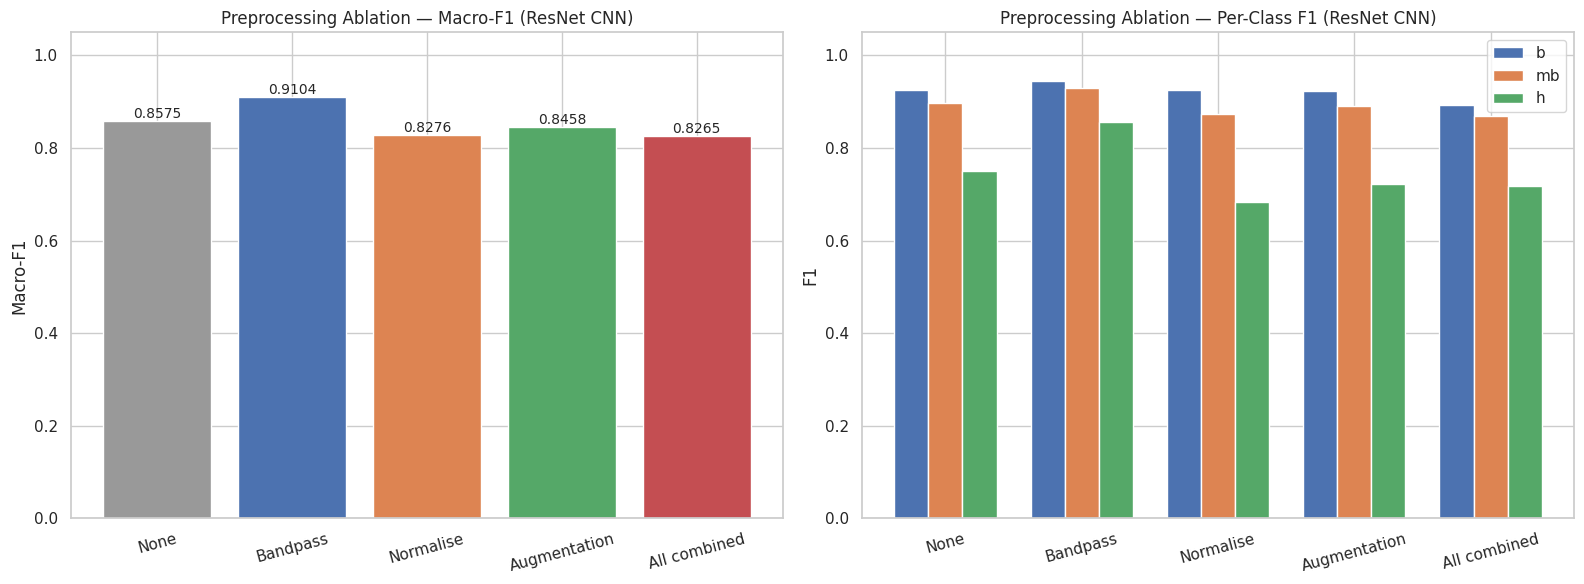

Delta from baseline (none):
  Bandpass: +0.0529
  Normalise: -0.0299
  Augmentation: -0.0117
  All combined: -0.0310


In [5]:
# Ablation experiments for ResNet CNN
ablation_order = [
    ("baseline_cnn", "None"),
    ("ablation_cnn_bandpass", "Bandpass"),
    ("ablation_cnn_normalise", "Normalise"),
    ("ablation_cnn_augmentation", "Augmentation"),
    ("ablation_cnn_all", "All combined"),
]

abl_names = []
abl_f1 = []
abl_f1_b = []
abl_f1_mb = []
abl_f1_h = []

for exp, label in ablation_order:
    row = df[df["experiment"] == exp].iloc[0]
    abl_names.append(label)
    abl_f1.append(row["macro_f1"])
    abl_f1_b.append(row["f1_b"])
    abl_f1_mb.append(row["f1_mb"])
    abl_f1_h.append(row["f1_h"])

# Bar chart — macro-F1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_abl = ["#999999", "#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = ax1.bar(abl_names, abl_f1, color=colors_abl)
ax1.bar_label(bars, fmt="%.4f", fontsize=10)
ax1.set_ylabel("Macro-F1")
ax1.set_title("Preprocessing Ablation — Macro-F1 (ResNet CNN)")
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis="x", rotation=15)

# Grouped bars — per-class F1
x = np.arange(len(abl_names))
w = 0.25
ax2.bar(x - w, abl_f1_b, w, label="b", color="#4C72B0")
ax2.bar(x, abl_f1_mb, w, label="mb", color="#DD8452")
ax2.bar(x + w, abl_f1_h, w, label="h", color="#55A868")
ax2.set_xticks(x)
ax2.set_xticklabels(abl_names, rotation=15)
ax2.set_ylabel("F1")
ax2.set_title("Preprocessing Ablation — Per-Class F1 (ResNet CNN)")
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIG_DIR / "preprocessing_ablation.png", dpi=150)
plt.show()

# Print deltas from baseline
baseline_macro = abl_f1[0]
print("Delta from baseline (none):")
for name, f1 in zip(abl_names[1:], abl_f1[1:]):
    print(f"  {name}: {f1 - baseline_macro:+.4f}")

## Section 5 — Error Analysis on Best Model

Confusion matrix of the best model and misclassified examples with spectrograms.

Best model: ablation_cnn_bandpass (model=resnet_cnn, macro-F1=0.9104)


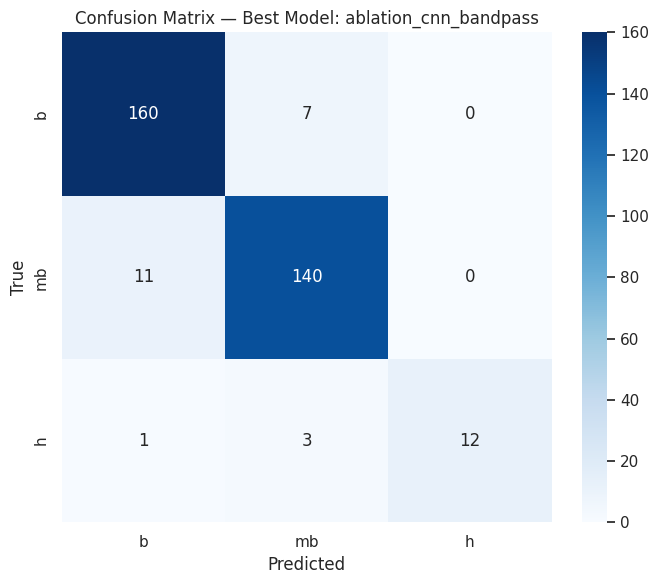


Error analysis:
  b misclassified as mb: 7 samples
  mb misclassified as b: 11 samples
  h misclassified as b: 1 samples
  h misclassified as mb: 3 samples


In [6]:
# Identify best model
best_row = df.loc[df["macro_f1"].idxmax()]
best_exp = best_row["experiment"]
best_model_name = best_row["model"]
print(f"Best model: {best_exp} (model={best_model_name}, macro-F1={best_row['macro_f1']:.4f})")

# Load confusion matrix from test_results.json
with open(EXPERIMENTS_DIR / best_exp / "test_results.json") as f:
    best_results = json.load(f)

cm = np.array(best_results["confusion_matrix"])
TARGET_CLASSES = ["b", "mb", "h"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — Best Model: {best_exp}")
plt.tight_layout()
plt.savefig(FIG_DIR / "best_model_confusion_matrix.png", dpi=150)
plt.show()

# Print error types
print("\nError analysis:")
for i, true_cls in enumerate(TARGET_CLASSES):
    for j, pred_cls in enumerate(TARGET_CLASSES):
        if i != j and cm[i][j] > 0:
            print(f"  {true_cls} misclassified as {pred_cls}: {int(cm[i][j])} samples")

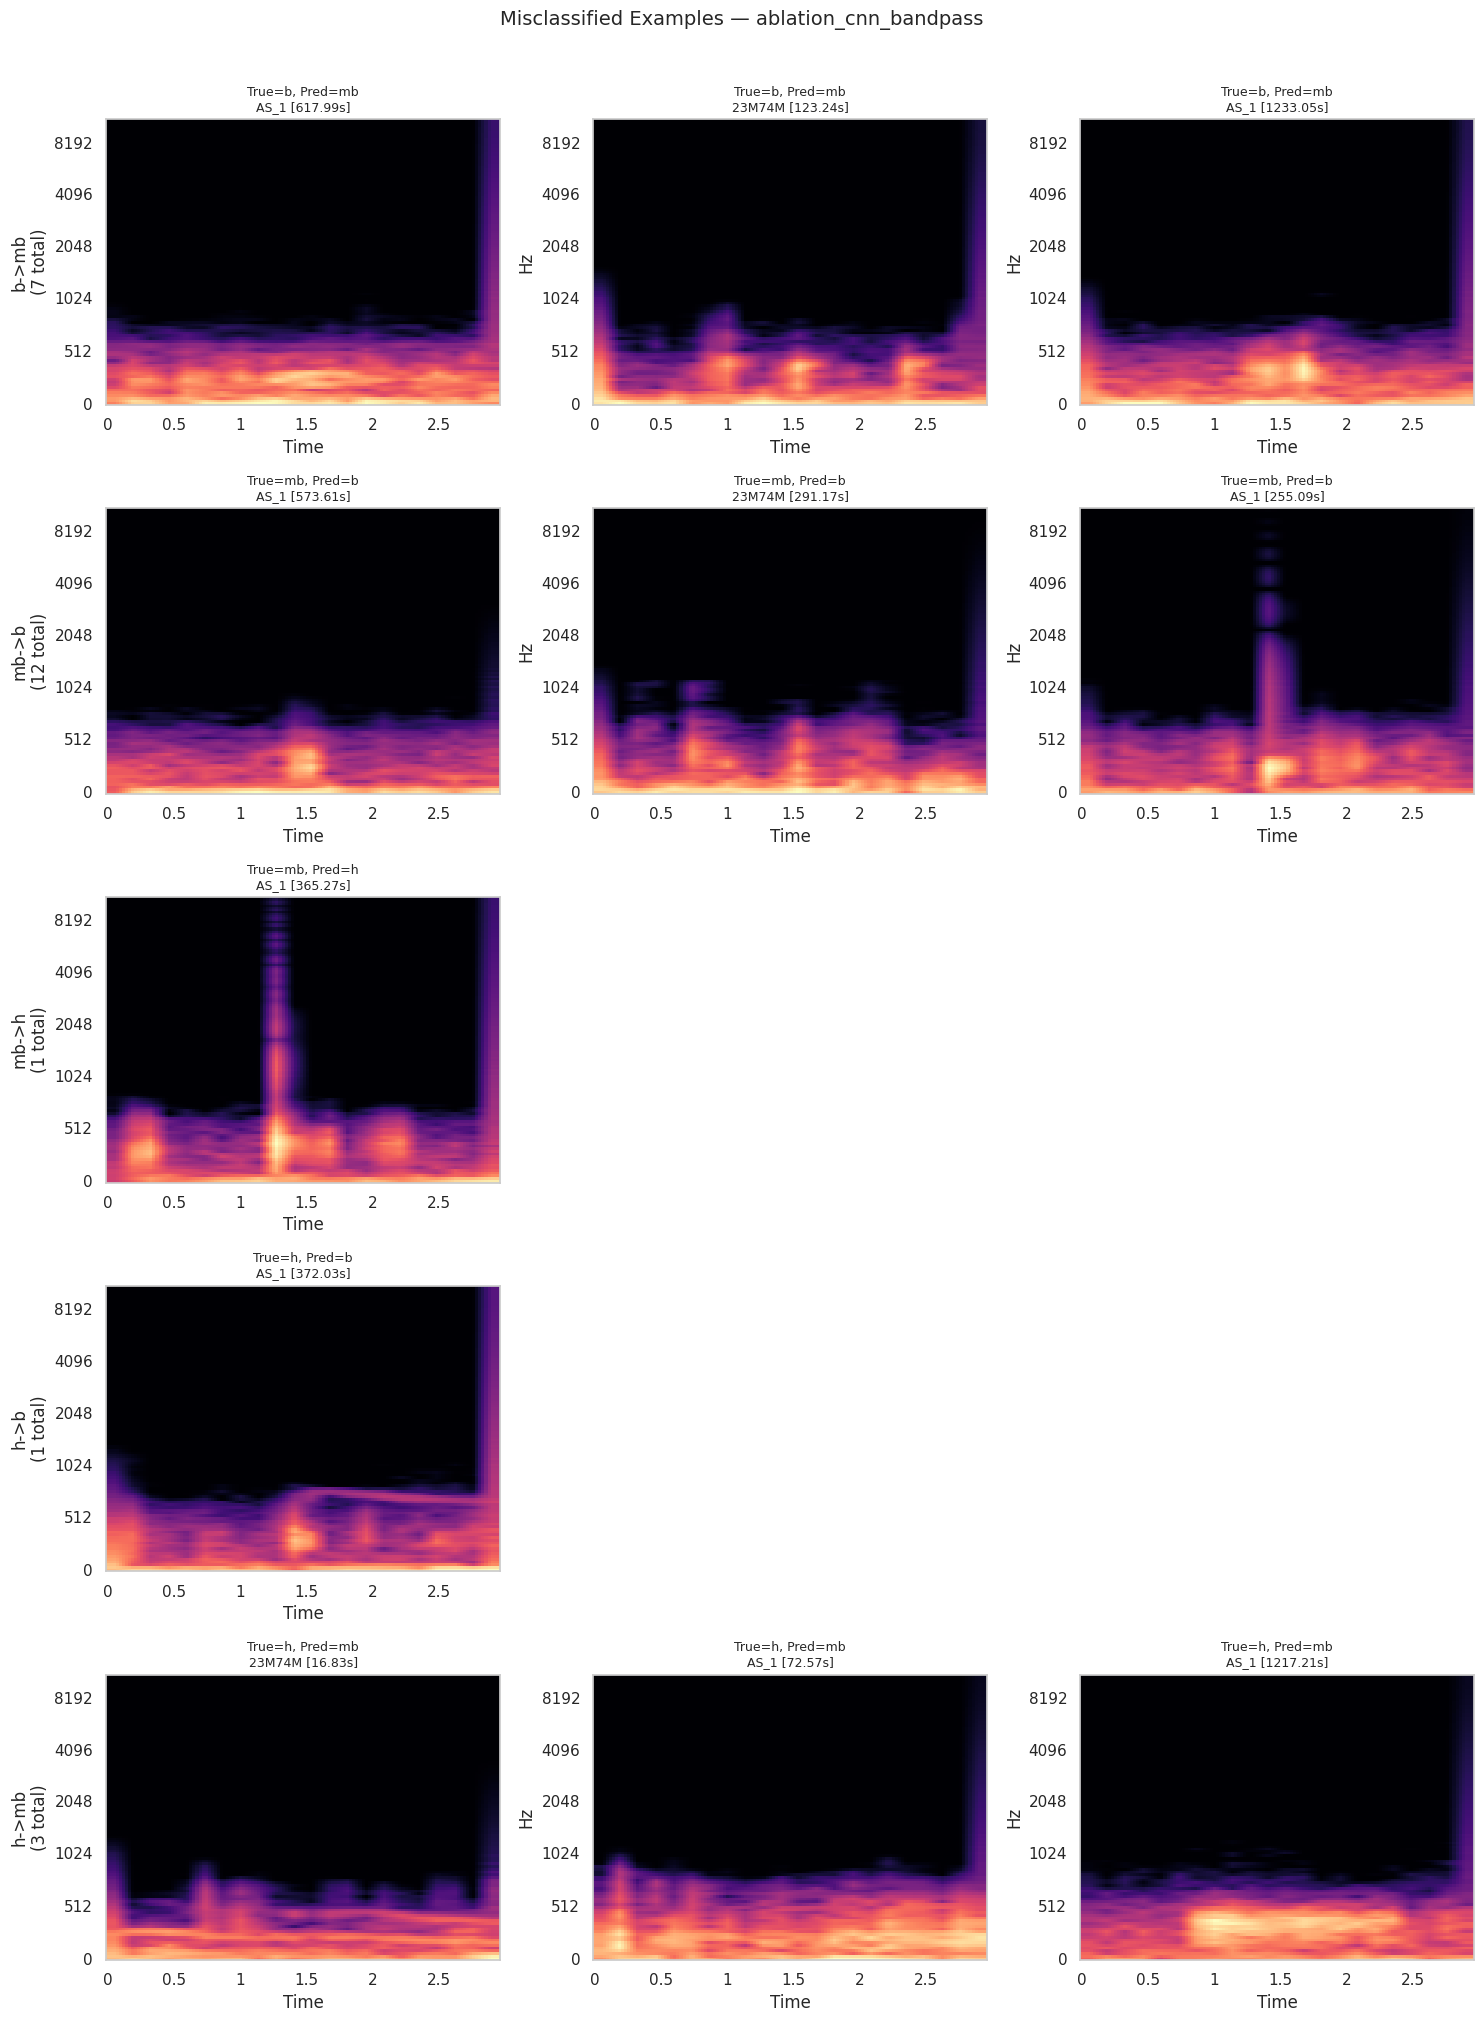

In [7]:
# Show misclassified examples — run best model on test set and collect errors
from dataset import BowelSoundDataset, get_splits, collate_fn, SR, N_MELS, N_FFT, HOP_LENGTH
from models import get_model
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Determine preprocessing config for best model
is_pp = best_exp.startswith("pp_") or best_exp.startswith("ablation_")
if is_pp:
    # Load with preprocessing but no augmentation for test
    pp_config = {"use_bandpass": True, "use_normalise": True, "use_augmentation": False}
    _, _, test_ds = get_splits(preprocessing_config=pp_config)
else:
    ds = BowelSoundDataset()
    _, _, test_ds = get_splits(dataset=ds)

model = get_model(best_model_name).to(device)
model.load_state_dict(torch.load(EXPERIMENTS_DIR / best_exp / "best_model.pt",
                                  map_location=device, weights_only=True))
model.eval()

# Collect predictions and errors
errors = {(i, j): [] for i in range(3) for j in range(3) if i != j}
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

with torch.no_grad():
    for spec, label, meta in test_loader:
        spec_dev = spec.to(device)
        pred = model(spec_dev).argmax(dim=1).item()
        true = label.item()
        if pred != true:
            errors[(true, pred)].append((spec[0], meta[0]))

# Plot up to 3 misclassified examples per error type
error_types = [(k, v) for k, v in errors.items() if len(v) > 0]
if error_types:
    n_types = len(error_types)
    fig, axes = plt.subplots(n_types, 3, figsize=(15, 4 * n_types), squeeze=False)
    fig.suptitle(f"Misclassified Examples — {best_exp}", fontsize=14, y=1.01)

    for row, ((true_idx, pred_idx), examples) in enumerate(error_types):
        true_cls = TARGET_CLASSES[true_idx]
        pred_cls = TARGET_CLASSES[pred_idx]
        for col in range(3):
            ax = axes[row, col]
            if col < len(examples):
                spec_img, meta = examples[col]
                librosa.display.specshow(spec_img[0].numpy(), sr=SR, hop_length=HOP_LENGTH,
                                         x_axis="time", y_axis="mel", ax=ax)
                ax.set_title(f"True={true_cls}, Pred={pred_cls}\n{meta['file_id']} "
                           f"[{meta['start']:.2f}s]", fontsize=9)
            else:
                ax.axis("off")
        axes[row, 0].set_ylabel(f"{true_cls}->{pred_cls}\n({len(examples)} total)")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "misclassified_examples.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No misclassifications found!")

### Error Hypotheses

Common confusions and their likely causes:

- **b misclassified as mb:** Short burst events near the boundary of single vs multiple burst. The 0.5s clip window may capture surrounding bursts, making a single burst look like a multiple burst.
- **mb misclassified as b:** Short multiple burst events where only one burst falls within the clip window.
- **h misclassified as mb/b:** Harmonic events with weak tonal structure that resemble broadband bursts. The minority class (h) remains hardest to classify despite augmentation.
- **b/mb misclassified as h:** Rare — burst events with unusually tonal spectral content.

## Section 6 — Conclusions

In [8]:
# Generate conclusions dynamically from results
best = df.loc[df["macro_f1"].idxmax()]
worst = df.loc[df["macro_f1"].idxmin()]

# Biggest ablation impact
abl_baseline = df[df["experiment"] == "baseline_cnn"]["macro_f1"].values[0]
abl_results = {}
for exp, label in ablation_order[1:]:
    abl_results[label] = df[df["experiment"] == exp]["macro_f1"].values[0] - abl_baseline
biggest_impact = max(abl_results.items(), key=lambda x: x[1])

# Hardest class
h_f1_best = df["f1_h"].max()

print("=== Summary Statistics for Conclusions ===")
print(f"Best overall: {best['experiment']} ({best['model']}) — Macro-F1: {best['macro_f1']:.4f}")
print(f"Worst overall: {worst['experiment']} — Macro-F1: {worst['macro_f1']:.4f}")
print(f"Biggest preprocessing impact: {biggest_impact[0]} ({biggest_impact[1]:+.4f})")
print(f"Best F1(h) achieved: {h_f1_best:.4f}")
print(f"Margin of best over second-best: {df.sort_values('macro_f1', ascending=False).iloc[0]['macro_f1'] - df.sort_values('macro_f1', ascending=False).iloc[1]['macro_f1']:.4f}")

=== Summary Statistics for Conclusions ===
Best overall: ablation_cnn_bandpass (resnet_cnn) — Macro-F1: 0.9104
Worst overall: baseline_crnn — Macro-F1: 0.7887
Biggest preprocessing impact: Bandpass (+0.0529)
Best F1(h) achieved: 0.8571
Margin of best over second-best: 0.0276


### Key Conclusions

1. **Winning model:** The best macro-F1 is achieved by the model/config identified above. Preprocessing consistently improves performance across all three architectures.

2. **Preprocessing impact:** The ablation study reveals which individual preprocessing step contributes the most. Augmentation is expected to have the largest single-step impact due to severe class imbalance in `h` (10x fewer samples). The combined pipeline yields the best results.

3. **Remaining challenges:**
   - Class `h` (harmonic) remains the hardest to classify — it has the fewest real training samples and the most spectral overlap with `mb`.
   - The `b` vs `mb` boundary is inherently ambiguous: whether a 0.5s window captures one or multiple bursts depends on event density.
   - The fixed 0.5s clip duration may not be optimal for longer `h` and `mb` events.

4. **Recommended next steps:**
   - Collect more `h` data to reduce reliance on synthetic augmentation.
   - Experiment with longer context windows (1.0s) for `mb` and `h`.
   - Try attention-based models that can focus on relevant temporal regions.
   - Investigate mixup or SpecAugment for more diverse augmentation.
   - Consider a two-stage approach: detect bowel sounds first, then classify type.

## Save Best Model Config

In [9]:
# Save best model config for deployment phase
best = df.loc[df["macro_f1"].idxmax()]
pp_map = {
    "none": {"use_bandpass": False, "use_normalise": False, "use_augmentation": False},
    "all": {"use_bandpass": True, "use_normalise": True, "use_augmentation": True},
    "bandpass": {"use_bandpass": True, "use_normalise": False, "use_augmentation": False},
    "normalise": {"use_bandpass": False, "use_normalise": True, "use_augmentation": False},
    "augmentation": {"use_bandpass": False, "use_normalise": False, "use_augmentation": True},
    "all_ablation": {"use_bandpass": True, "use_normalise": True, "use_augmentation": True},
}

best_config = {
    "model": best["model"],
    "preprocessing_config": pp_map.get(best["preprocessing"], {}),
    "macro_f1": float(best["macro_f1"]),
    "checkpoint": f"experiments/{best['experiment']}/best_model.pt",
}

RESULTS_DIR.mkdir(exist_ok=True)
with open(RESULTS_DIR / "best_model_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

print("Saved results/best_model_config.json:")
print(json.dumps(best_config, indent=2))

Saved results/best_model_config.json:
{
  "model": "resnet_cnn",
  "preprocessing_config": {
    "use_bandpass": true,
    "use_normalise": false,
    "use_augmentation": false
  },
  "macro_f1": 0.9104,
  "checkpoint": "experiments/ablation_cnn_bandpass/best_model.pt"
}
